#### Extracting computer vision features

In [1]:
import cv2 as cv

In [ ]:
img = cv.imread(
    "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grid_images/grid_64491.png"
)

cv.imshow("Image", img)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
#   CV features description:

#   1. edge_density (Proxy for Building Dispersion/Clutter)
#   A tightly packed Kirana market (High Potential) has thousands of tiny,
#   overlapping roofs, creating massive high-frequency visual noise
#   Canny Edge Detector

#   2. structural_complexity_score (Proxy for Intersections & Connectivity)
#   Perfect road skeletonization is often prone to errors. A more robust metric is
#   counting the absolute number of geometric corners in the image
#   Shi-Tomasi Corner Detection

#   3. green_cover_ratio (The Breathability Index)
#   High-potential FMCG grids in India are often concrete jungles with near-zero greenery
#   Convert to HSV color space

In [3]:
import cv2
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

/Users/saranyapal/Developer/grid-determination-bizom/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Define your directory
IMAGE_DIR = (
    "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grid_images"
)

In [ ]:
def extract_image_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    total_pixels = img.shape[0] * img.shape[1]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 30, 30])
    upper_green = np.array([95, 255, 255])

    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    green_pixels = cv2.countNonZero(green_mask)
    green_cover_ratio = green_pixels / total_pixels

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    edges = cv2.Canny(blurred, 50, 150)
    edge_pixels = cv2.countNonZero(edges)
    edge_density = edge_pixels / total_pixels

    corners = cv2.goodFeaturesToTrack(
        gray, maxCorners=10000, qualityLevel=0.01, minDistance=5
    )
    corner_count = len(corners) if corners is not None else 0
    structural_complexity = (corner_count / total_pixels) * 10000

    return {
        "green_cover_ratio": green_cover_ratio,
        "edge_density": edge_density,
        "structural_complexity": structural_complexity,
    }

In [ ]:
features_list = []
valid_extensions = ".png"

for filename in tqdm(os.listdir(IMAGE_DIR)):
    if filename.lower().endswith(valid_extensions):
        try:
            grid_id = int(filename.split("_")[1].split(".")[0])
        except (IndexError, ValueError):
            continue

        filepath = os.path.join(IMAGE_DIR, filename)
        features = extract_image_features(filepath)

        if features:
            features["grid_id"] = grid_id
            features_list.append(features)

image_features_df = pd.DataFrame(features_list)

100%|██████████| 2000/2000 [00:02<00:00, 884.39it/s]


In [23]:
sorted_image_features_df = image_features_df.sort_values(
    by="grid_id", ascending=True
).reset_index(drop=True)

In [24]:
sorted_image_features_df.head()

,green_cover_ratio,edge_density,structural_complexity,grid_id
0,0.989894,0.004513,2.2500,157
1,0.003938,0.018531,4.7500,209
2,0.000000,0.028463,9.5000,221
3,0.000000,0.036937,10.9375,222
4,0.000000,0.033050,12.0000,230


In [25]:
from matplotlib import pyplot as plt
import seaborn as sns

In [26]:
sorted_image_features_df.drop(columns="grid_id", axis=1).corr()

,green_cover_ratio,edge_density,structural_complexity
green_cover_ratio,1.000000,-0.520043,-0.424744
edge_density,-0.520043,1.000000,0.809968
structural_complexity,-0.424744,0.809968,1.000000


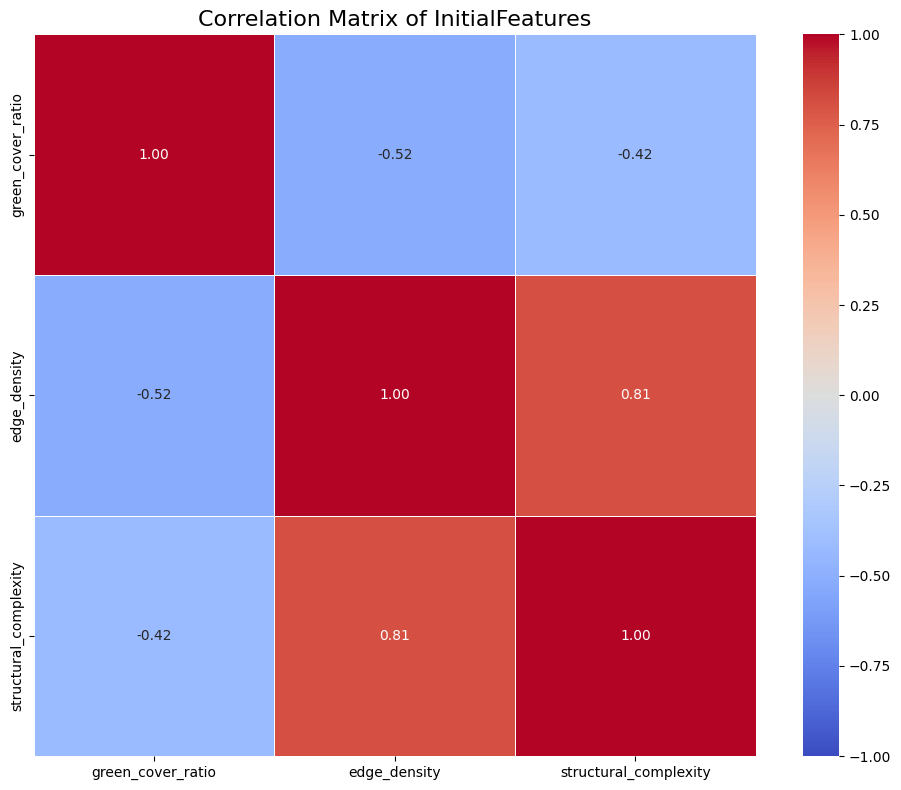

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    sorted_image_features_df.drop(columns="grid_id", axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of InitialFeatures", fontsize=16)
plt.tight_layout()